In [1]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

In [3]:
df2 = pd.read_csv(r"D:\Master Of Data Science And AI\Capstone\model\data\dataset2\Indoor Fire Dataset with Distributed Multi-Sensor Nodes_Industrial Hall.csv")
print(df2.shape)
df2.head()

(248502, 23)


,Date,Sensor_ID,CO2_Room,scenario_label,progress_label,experiment_number,H2_Room,PM05_Room,PM100_Room,PM10_Room,...,PM_Total_Room,VOC_Room_RAW,Valid_Experiment,fire,nuisance,Temperature_Room,Humidity_Room,CO_Room,anomaly_label,anomaly_scenario
0,2023-07-10 09:30:27+02:00,sensornode0009,926.0,Background,Ignition,0.0,0.0,22.0,0.0,3.0,...,25.0,0.1,1.0,0.0,0.0,28.2,47.0,0.54,0.0,NaN
1,2023-07-10 09:30:27+02:00,sensornode0008,821.0,Background,Ignition,0.0,0.0,23.0,0.0,3.0,...,26.0,0.2,1.0,0.0,0.0,28.2,48.1,0.31,0.0,NaN
2,2023-07-10 09:30:30+02:00,sensornode0010,599.0,Background,Ignition,0.0,0.2,19.0,0.0,2.0,...,22.0,0.0,1.0,0.0,0.0,27.7,48.4,0.10,0.0,NaN
3,2023-07-10 09:30:32+02:00,sensornode0012,919.0,Background,Ignition,0.0,0.1,21.0,0.0,3.0,...,24.0,0.0,1.0,0.0,0.0,27.3,47.9,0.13,0.0,NaN
4,2023-07-10 09:30:33+02:00,sensornode0015,737.0,Background,Ignition,0.0,0.1,22.0,0.0,3.0,...,25.0,0.0,1.0,0.0,0.0,27.0,49.4,0.00,0.0,NaN


In [4]:
df2.columns

Index(['Date', 'Sensor_ID', 'CO2_Room', 'scenario_label', 'progress_label',
       'experiment_number', 'H2_Room', 'PM05_Room', 'PM100_Room', 'PM10_Room',
       'PM25_Room', 'PM40_Room', 'PM_Room_Typical_Size', 'PM_Total_Room',
       'VOC_Room_RAW', 'Valid_Experiment', 'fire', 'nuisance',
       'Temperature_Room', 'Humidity_Room', 'CO_Room', 'anomaly_label',
       'anomaly_scenario'],
      dtype='object')

In [5]:
features2 = [
    "Temperature_Room",
    "Humidity_Room",
    "CO_Room",
    "CO2_Room",
    "PM25_Room",
    "PM10_Room",
    "VOC_Room_RAW"
]

In [6]:
df2_model = df2[features2].copy()

for col in features2:
    df2_model[col] = pd.to_numeric(df2_model[col], errors="coerce")

df2_model = df2_model.ffill().bfill()

print(df2_model.isna().sum())

Temperature_Room    0
Humidity_Room       0
CO_Room             0
CO2_Room            0
PM25_Room           0
PM10_Room           0
VOC_Room_RAW        0
dtype: int64


In [7]:
import numpy as np
import pandas as pd

# --- raw feature table ---
df2_model = df2[features2].copy()
for col in features2:
    df2_model[col] = pd.to_numeric(df2_model[col], errors="coerce")
df2_model = df2_model.ffill().bfill()

# --- labels ---
fire_all = df2["fire"].astype(int).values


n = len(df2_model)
train_end = int(n * 0.70)
val_end = int(n * 0.80)

df2_train_full = df2_model.iloc[:train_end].copy()
df2_val_full   = df2_model.iloc[train_end:val_end].copy()
df2_test_full  = df2_model.iloc[val_end:].copy()

fire_train_full = fire_all[:train_end]
fire_val_full   = fire_all[train_end:val_end]
fire_test_full  = fire_all[val_end:]

print(df2_train_full.shape, df2_val_full.shape, df2_test_full.shape)
print(pd.Series(fire_train_full).value_counts())
print(pd.Series(fire_val_full).value_counts())
print(pd.Series(fire_test_full).value_counts())

(173951, 7) (24850, 7) (49701, 7)
0    154926
1     19025
Name: count, dtype: int64
0    21936
1     2914
Name: count, dtype: int64
0    44119
1     5582
Name: count, dtype: int64


In [8]:

df2_train_normal = df2_train_full[fire_train_full == 0].copy()
print("Train normal shape:", df2_train_normal.shape)

Train normal shape: (154926, 7)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X2_train_normal = scaler2.fit_transform(df2_train_normal)
X2_train_full   = scaler2.transform(df2_train_full)
X2_val_full     = scaler2.transform(df2_val_full)
X2_test_full    = scaler2.transform(df2_test_full)

print(X2_train_normal.shape, X2_train_full.shape, X2_val_full.shape, X2_test_full.shape)

(154926, 7) (173951, 7) (24850, 7) (49701, 7)


In [10]:
import numpy as np

def make_windows(X, labels, window_size=60, horizon=1):
    X_windows = []
    y_windows = []
    y_labels = []

    for i in range(len(X) - window_size - horizon + 1):
        X_windows.append(X[i:i+window_size])
        y_windows.append(X[i+window_size+horizon-1])
        y_labels.append(labels[i+window_size+horizon-1])

    return (
        np.array(X_windows, dtype=np.float32),
        np.array(y_windows, dtype=np.float32),
        np.array(y_labels, dtype=np.int32)
    )

In [11]:
window_size = 120
horizon = 5


X_train_tcn, y_train_tcn, _ = make_windows(
    X2_train_normal,
    np.zeros(len(X2_train_normal), dtype=int),
    window_size=window_size,
    horizon=horizon
)


X_train_full_w, y_train_full_w, fire_train_w = make_windows(
    X2_train_full,
    fire_train_full,
    window_size=window_size,
    horizon=horizon
)

X_val_full_w, y_val_full_w, fire_val_w = make_windows(
    X2_val_full,
    fire_val_full,
    window_size=window_size,
    horizon=horizon
)

X_test_full_w, y_test_full_w, fire_test_w = make_windows(
    X2_test_full,
    fire_test_full,
    window_size=window_size,
    horizon=horizon
)

print(X_train_tcn.shape, y_train_tcn.shape)
print(X_val_full_w.shape, y_val_full_w.shape, fire_val_w.shape)
print(X_test_full_w.shape, y_test_full_w.shape, fire_test_w.shape)

(154802, 120, 7) (154802, 7)
(24726, 120, 7) (24726, 7) (24726,)
(49577, 120, 7) (49577, 7) (49577,)


In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    torch.tensor(X_train_tcn),
    torch.tensor(y_train_tcn)
)

val_dataset = TensorDataset(
    torch.tensor(X_val_full_w),
    torch.tensor(y_val_full_w)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [13]:
import torch
import torch.nn as nn

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size]

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.dropout1,
            self.conv2, self.chomp2, self.relu2, self.dropout2
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCNForecaster(nn.Module):
    def __init__(self, input_size, channels=[32, 64], kernel_size=3, dropout=0.2, output_size=7):
        super().__init__()
        layers = []
        in_channels = input_size

        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(in_channels, out_channels, kernel_size, dilation, dropout)
            )
            in_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], output_size)

    def forward(self, x):
        x = x.transpose(1, 2)
        y = self.tcn(x)
        y = y[:, :, -1]
        y = self.fc(y)
        return y

In [14]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: False


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model2 = TCNForecaster(
    input_size=len(features2),
    channels=[32, 64],
    kernel_size=3,
    dropout=0.2,
    output_size=len(features2)
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)

best_val_loss = float("inf")
best_state = None
patience = 5
patience_counter = 0

train_losses = []
val_losses = []

epochs = 30

for epoch in range(epochs):
    # train
    model2.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model2(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # val
    model2.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model2(xb)
            loss = criterion(pred, yb)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f}")

    # early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = model2.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

# restore best
model2.load_state_dict(best_state)
print("Best val loss:", best_val_loss)

Epoch 1/30 | Train: 0.275131 | Val: 0.781327
Epoch 2/30 | Train: 0.227054 | Val: 0.556705
Epoch 3/30 | Train: 0.225494 | Val: 0.389303
Epoch 4/30 | Train: 0.174307 | Val: 0.624446
Epoch 5/30 | Train: 0.173007 | Val: 0.723186
Epoch 6/30 | Train: 0.173697 | Val: 0.935255
Epoch 7/30 | Train: 0.190862 | Val: 0.464192
Epoch 8/30 | Train: 0.195115 | Val: 0.843596
Early stopping triggered.
Best val loss: 0.38930269867634204


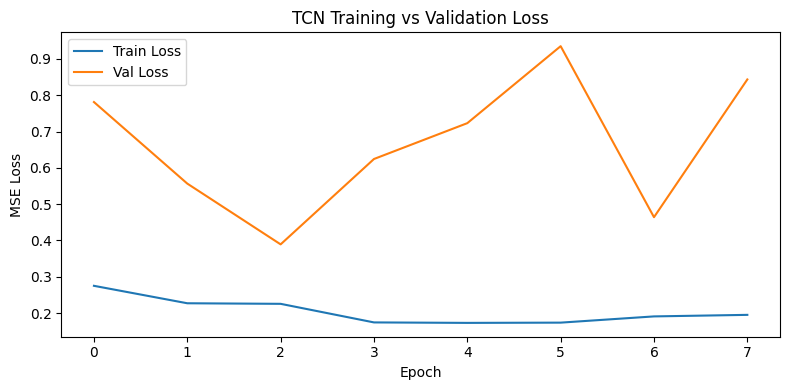

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("TCN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
def get_residuals_batched_safe(model, X_windows, y_windows, device, batch_size=128):
    model.eval()
    residuals_list = []

    with torch.no_grad():
        for start in range(0, len(X_windows), batch_size):
            end = start + batch_size

            xb = torch.tensor(X_windows[start:end], dtype=torch.float32).to(device)
            yb = torch.tensor(y_windows[start:end], dtype=torch.float32).to(device)

            y_pred = model(xb)
            batch_residuals = torch.abs(y_pred - yb).cpu().numpy()
            residuals_list.append(batch_residuals)

    residuals = np.vstack(residuals_list)
    residual_score = residuals.mean(axis=1)

    return residuals, residual_score

In [18]:
residuals_train, residual_score_train = get_residuals_batched_safe(
    model2, X_train_full_w, y_train_full_w, device, batch_size=128
)

residuals_val, residual_score_val = get_residuals_batched_safe(
    model2, X_val_full_w, y_val_full_w, device, batch_size=128
)

residuals_test, residual_score_test = get_residuals_batched_safe(
    model2, X_test_full_w, y_test_full_w, device, batch_size=128
)

In [19]:
risk_min = residual_score_train.min()
risk_max = residual_score_train.max()

risk_train = (residual_score_train - risk_min) / (risk_max - risk_min + 1e-8)
risk_val   = (residual_score_val   - risk_min) / (risk_max - risk_min + 1e-8)
risk_test  = (residual_score_test  - risk_min) / (risk_max - risk_min + 1e-8)

In [20]:
def build_residual_feature_df(residuals, residual_score, feature_names):
    df_feat = pd.DataFrame()

    # overall stats
    df_feat["residual_mean"] = residuals.mean(axis=1)
    df_feat["residual_max"] = residuals.max(axis=1)
    df_feat["residual_std"] = residuals.std(axis=1)
    df_feat["residual_min"] = residuals.min(axis=1)
    df_feat["residual_range"] = residuals.max(axis=1) - residuals.min(axis=1)
    df_feat["residual_score"] = residual_score

    # per-sensor residuals
    for i, name in enumerate(feature_names):
        df_feat[f"{name}_residual"] = residuals[:, i]

    # top-2 residuals
    sorted_res = np.sort(residuals, axis=1)
    df_feat["top1_residual"] = sorted_res[:, -1]
    df_feat["top2_residual"] = sorted_res[:, -2]

    return df_feat

feat_train = build_residual_feature_df(residuals_train, residual_score_train, features2)
feat_val   = build_residual_feature_df(residuals_val, residual_score_val, features2)
feat_test  = build_residual_feature_df(residuals_test, residual_score_test, features2)

feat_train["risk_tcn"] = risk_train
feat_val["risk_tcn"] = risk_val
feat_test["risk_tcn"] = risk_test

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


normal_idx_train = residual_score_train < np.percentile(residual_score_train, 15)

scaler_iso2 = StandardScaler()
feat_train_scaled = scaler_iso2.fit_transform(feat_train)
feat_val_scaled   = scaler_iso2.transform(feat_val)
feat_test_scaled  = scaler_iso2.transform(feat_test)

feat_train_normal_scaled = feat_train_scaled[normal_idx_train]

iso2 = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42
)

iso2.fit(feat_train_normal_scaled)

iso_train_raw = iso2.score_samples(feat_train_scaled)
iso_val_raw   = iso2.score_samples(feat_val_scaled)
iso_test_raw  = iso2.score_samples(feat_test_scaled)

iso_train = (iso_train_raw.max() - iso_train_raw) / (iso_train_raw.max() - iso_train_raw.min() + 1e-8)
iso_val   = (iso_train_raw.max() - iso_val_raw)   / (iso_train_raw.max() - iso_train_raw.min() + 1e-8)
iso_test  = (iso_train_raw.max() - iso_test_raw)  / (iso_train_raw.max() - iso_train_raw.min() + 1e-8)

feat_train["iso_score"] = iso_train
feat_val["iso_score"] = iso_val
feat_test["iso_score"] = iso_test

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


normal_idx_train = residual_score_train < np.percentile(residual_score_train, 15)

scaler_iso2 = StandardScaler()
feat_train_scaled = scaler_iso2.fit_transform(feat_train)
feat_val_scaled   = scaler_iso2.transform(feat_val)
feat_test_scaled  = scaler_iso2.transform(feat_test)

feat_train_normal_scaled = feat_train_scaled[normal_idx_train]

iso2 = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42
)

iso2.fit(feat_train_normal_scaled)

iso_train_raw = iso2.score_samples(feat_train_scaled)
iso_val_raw   = iso2.score_samples(feat_val_scaled)
iso_test_raw  = iso2.score_samples(feat_test_scaled)

iso_train = (iso_train_raw.max() - iso_train_raw) / (iso_train_raw.max() - iso_train_raw.min() + 1e-8)
iso_val   = (iso_train_raw.max() - iso_val_raw)   / (iso_train_raw.max() - iso_train_raw.min() + 1e-8)
iso_test  = (iso_train_raw.max() - iso_test_raw)  / (iso_train_raw.max() - iso_train_raw.min() + 1e-8)

feat_train["iso_score"] = iso_train
feat_val["iso_score"] = iso_val
feat_test["iso_score"] = iso_test

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

X_train_ae = torch.tensor(feat_train_scaled[normal_idx_train], dtype=torch.float32)
X_val_ae   = torch.tensor(feat_val_scaled, dtype=torch.float32)
X_test_ae  = torch.tensor(feat_test_scaled, dtype=torch.float32)
X_train_all_ae = torch.tensor(feat_train_scaled, dtype=torch.float32)

ae_loader = DataLoader(
    TensorDataset(X_train_ae, X_train_ae),
    batch_size=32,
    shuffle=True
)

class AE2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16)
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

ae2 = AE2(input_dim=feat_train_scaled.shape[1]).to(device)
criterion_ae = nn.MSELoss()
optimizer_ae = torch.optim.Adam(ae2.parameters(), lr=1e-3)

ae_losses = []

for epoch in range(40):
    ae2.train()
    total_loss = 0.0

    for xb, _ in ae_loader:
        xb = xb.to(device)
        optimizer_ae.zero_grad()
        recon = ae2(xb)
        loss = criterion_ae(recon, xb)
        loss.backward()
        optimizer_ae.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(ae_loader)
    ae_losses.append(avg_loss)
    print(f"AE Epoch {epoch+1}/40 | Loss: {avg_loss:.6f}")

AE Epoch 1/40 | Loss: 0.015956
AE Epoch 2/40 | Loss: 0.001234
AE Epoch 3/40 | Loss: 0.000329
AE Epoch 4/40 | Loss: 0.000062
AE Epoch 5/40 | Loss: 0.000046
AE Epoch 6/40 | Loss: 0.000044
AE Epoch 7/40 | Loss: 0.000042
AE Epoch 8/40 | Loss: 0.000041
AE Epoch 9/40 | Loss: 0.000039
AE Epoch 10/40 | Loss: 0.000039
AE Epoch 11/40 | Loss: 0.000037
AE Epoch 12/40 | Loss: 0.000036
AE Epoch 13/40 | Loss: 0.000035
AE Epoch 14/40 | Loss: 0.000033
AE Epoch 15/40 | Loss: 0.000030
AE Epoch 16/40 | Loss: 0.000024
AE Epoch 17/40 | Loss: 0.000020
AE Epoch 18/40 | Loss: 0.000020
AE Epoch 19/40 | Loss: 0.000021
AE Epoch 20/40 | Loss: 0.000019
AE Epoch 21/40 | Loss: 0.000018
AE Epoch 22/40 | Loss: 0.000019
AE Epoch 23/40 | Loss: 0.000018
AE Epoch 24/40 | Loss: 0.000019
AE Epoch 25/40 | Loss: 0.000018
AE Epoch 26/40 | Loss: 0.000018
AE Epoch 27/40 | Loss: 0.000018
AE Epoch 28/40 | Loss: 0.000019
AE Epoch 29/40 | Loss: 0.000017
AE Epoch 30/40 | Loss: 0.000018
AE Epoch 31/40 | Loss: 0.000018
AE Epoch 32/40 | 

In [24]:
def get_ae_score(model, X_tensor, device):
    model.eval()
    with torch.no_grad():
        X_tensor = X_tensor.to(device)
        recon = model(X_tensor)
        err = torch.mean((X_tensor - recon) ** 2, dim=1).cpu().numpy()
    return err

ae_train_raw = get_ae_score(ae2, X_train_all_ae, device)
ae_val_raw   = get_ae_score(ae2, X_val_ae, device)
ae_test_raw  = get_ae_score(ae2, X_test_ae, device)

ae_min = ae_train_raw.min()
ae_max = ae_train_raw.max()

ae_train = (ae_train_raw - ae_min) / (ae_max - ae_min + 1e-8)
ae_val   = (ae_val_raw - ae_min) / (ae_max - ae_min + 1e-8)
ae_test  = (ae_test_raw - ae_min) / (ae_max - ae_min + 1e-8)

feat_train["ae_score"] = ae_train
feat_val["ae_score"] = ae_val
feat_test["ae_score"] = ae_test

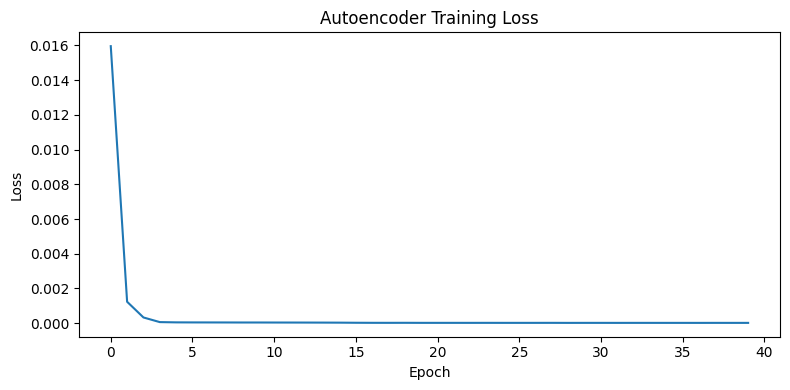

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(ae_losses)
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

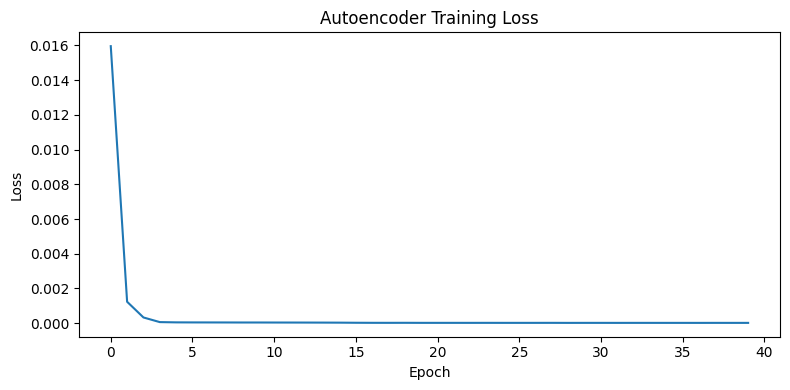

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(ae_losses)
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [27]:
fusion_train = feat_train.copy()
fusion_val   = feat_val.copy()
fusion_test  = feat_test.copy()

fusion_train["label"] = fire_train_w.astype(int)
fusion_val["label"]   = fire_val_w.astype(int)
fusion_test["label"]  = fire_test_w.astype(int)

print(fusion_train.shape, fusion_val.shape, fusion_test.shape)

(173827, 19) (24726, 19) (49577, 19)


In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train = fusion_train.drop(columns=["label"])
y_train = fusion_train["label"]

X_val = fusion_val.drop(columns=["label"])
y_val = fusion_val["label"]

X_test = fusion_test.drop(columns=["label"])
y_test = fusion_test["label"]

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb2.fit(X_train, y_train)

val_probs = xgb2.predict_proba(X_val)[:, 1]
test_probs = xgb2.predict_proba(X_test)[:, 1]

val_pred_default = (val_probs >= 0.5).astype(int)
test_pred_default = (test_probs >= 0.5).astype(int)

print("VAL")
print(classification_report(y_val, val_pred_default, zero_division=0))

print("TEST")
print(classification_report(y_test, test_pred_default, zero_division=0))

VAL
              precision    recall  f1-score   support

           0       0.98      0.50      0.66     21812
           1       0.20      0.94      0.33      2914

    accuracy                           0.55     24726
   macro avg       0.59      0.72      0.50     24726
weighted avg       0.89      0.55      0.62     24726

TEST
              precision    recall  f1-score   support

           0       0.95      0.15      0.26     43995
           1       0.12      0.93      0.22      5582

    accuracy                           0.24     49577
   macro avg       0.53      0.54      0.24     49577
weighted avg       0.85      0.24      0.26     49577



In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train = fusion_train.drop(columns=["label"])
y_train = fusion_train["label"]

X_val = fusion_val.drop(columns=["label"])
y_val = fusion_val["label"]

X_test = fusion_test.drop(columns=["label"])
y_test = fusion_test["label"]

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb2.fit(X_train, y_train)

val_probs = xgb2.predict_proba(X_val)[:, 1]
test_probs = xgb2.predict_proba(X_test)[:, 1]

val_pred_default = (val_probs >= 0.5).astype(int)
test_pred_default = (test_probs >= 0.5).astype(int)

print("VAL")
print(classification_report(y_val, val_pred_default, zero_division=0))

print("TEST")
print(classification_report(y_test, test_pred_default, zero_division=0))

VAL
              precision    recall  f1-score   support

           0       0.98      0.50      0.66     21812
           1       0.20      0.94      0.33      2914

    accuracy                           0.55     24726
   macro avg       0.59      0.72      0.50     24726
weighted avg       0.89      0.55      0.62     24726

TEST
              precision    recall  f1-score   support

           0       0.95      0.15      0.26     43995
           1       0.12      0.93      0.22      5582

    accuracy                           0.24     49577
   macro avg       0.53      0.54      0.24     49577
weighted avg       0.85      0.24      0.26     49577



In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

def persistence_filter(risk, threshold=0.2, min_len=2):
    out = np.zeros(len(risk), dtype=int)
    count = 0
    for i, r in enumerate(risk):
        if r >= threshold:
            count += 1
        else:
            count = 0
        if count >= min_len:
            out[i] = 1
    return out

search_rows = []

for t in np.linspace(0.10, 0.50, 21):
    for m in [1, 2, 3, 4, 5]:
        pred = persistence_filter(val_probs, threshold=float(t), min_len=int(m))

        prec = precision_score(y_val, pred, zero_division=0)
        rec  = recall_score(y_val, pred, zero_division=0)
        f1   = f1_score(y_val, pred, zero_division=0)

        search_rows.append({
            "threshold": round(float(t), 4),
            "min_len": int(m),
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "alarms": int(pred.sum())
        })

df_search = pd.DataFrame(search_rows)
print(df_search.sort_values(["f1", "recall"], ascending=False).head(10))

     threshold  min_len  precision    recall        f1  alarms
104       0.50        5   0.484069  0.813315  0.606914    4896
99        0.48        5   0.451991  0.833562  0.586149    5374
94        0.46        5   0.419808  0.871311  0.566615    6048
103       0.50        4   0.412296  0.830817  0.551104    5872
89        0.44        5   0.388111  0.893960  0.541242    6712
98        0.48        4   0.379042  0.852780  0.524815    6556
84        0.42        5   0.352544  0.913178  0.508698    7548
93        0.46        4   0.351044  0.888813  0.503304    7378
79        0.40        5   0.325153  0.927591  0.481518    8313
102       0.50        3   0.331877  0.859986  0.478930    7551


In [31]:
best_row = df_search.sort_values(["f1", "recall"], ascending=False).iloc[0]
best_threshold = float(best_row["threshold"])
best_min_len = int(best_row["min_len"])

print("Chosen threshold:", best_threshold)
print("Chosen min_len:", best_min_len)

Chosen threshold: 0.5
Chosen min_len: 5


In [32]:
df2_test_result = X_test.copy()
df2_test_result["TrueLabel"] = y_test.values
df2_test_result["FinalRisk"] = test_probs


df2_test_result = df2_test_result.sort_index()

df2_test_result["FinalAlarm"] = persistence_filter(
    df2_test_result["FinalRisk"].values,
    threshold=best_threshold,
    min_len=best_min_len
)

print(df2_test_result["FinalAlarm"].value_counts())
print(classification_report(
    df2_test_result["TrueLabel"].astype(int),
    df2_test_result["FinalAlarm"].astype(int),
    zero_division=0
))

FinalAlarm
1    30507
0    19070
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.93      0.40      0.56     43995
           1       0.14      0.75      0.23      5582

    accuracy                           0.44     49577
   macro avg       0.53      0.58      0.40     49577
weighted avg       0.84      0.44      0.52     49577



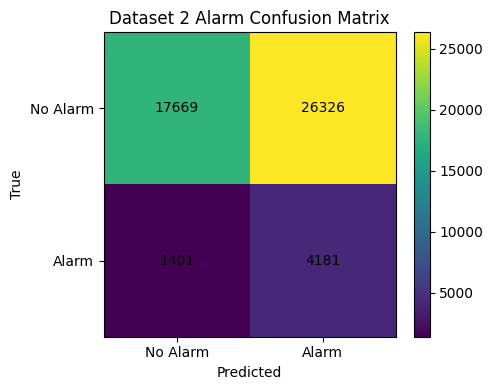

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

true_alarm = df2_test_result["TrueLabel"].astype(int)
pred_alarm = df2_test_result["FinalAlarm"].astype(int)

cm = confusion_matrix(true_alarm, pred_alarm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, aspect="auto")
plt.colorbar()
plt.xticks([0, 1], ["No Alarm", "Alarm"])
plt.yticks([0, 1], ["No Alarm", "Alarm"])
plt.title("Dataset 2 Alarm Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

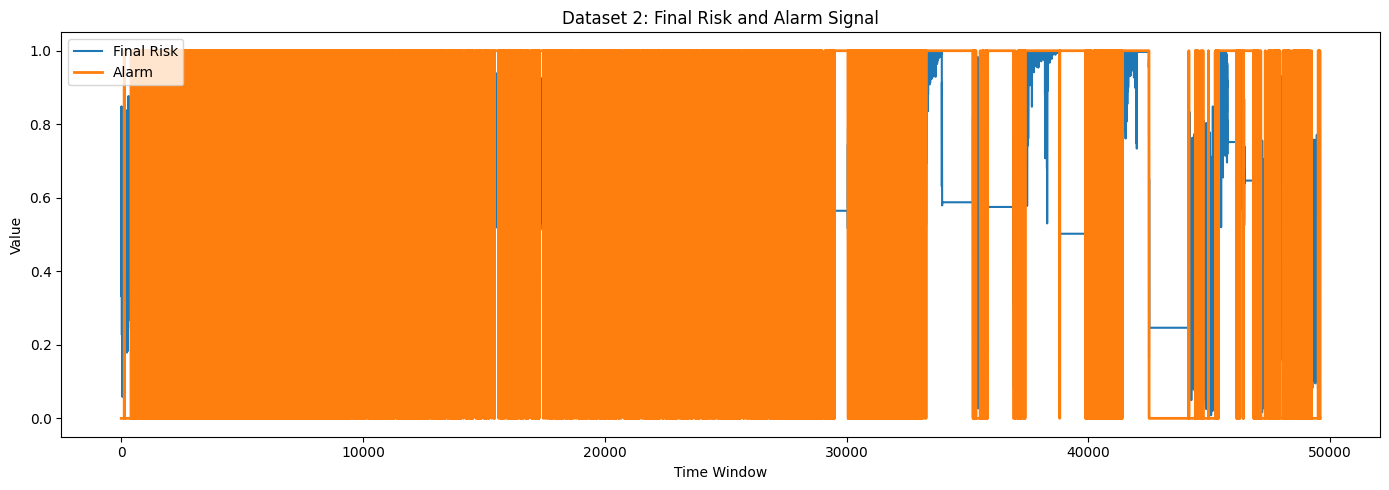

In [34]:
plt.figure(figsize=(14, 5))
plt.plot(df2_test_result["FinalRisk"].values, label="Final Risk")
plt.plot(df2_test_result["FinalAlarm"].values, label="Alarm", linewidth=2)
plt.title("Dataset 2: Final Risk and Alarm Signal")
plt.xlabel("Time Window")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

PM10_Room_residual           0.269448
top2_residual                0.261177
iso_score                    0.101024
residual_mean                0.096123
residual_score               0.026637
CO_Room_residual             0.022777
top1_residual                0.021198
VOC_Room_RAW_residual        0.021170
ae_score                     0.020863
residual_max                 0.019817
Temperature_Room_residual    0.019153
PM25_Room_residual           0.018970
Humidity_Room_residual       0.018953
CO2_Room_residual            0.018952
risk_tcn                     0.018868
dtype: float32


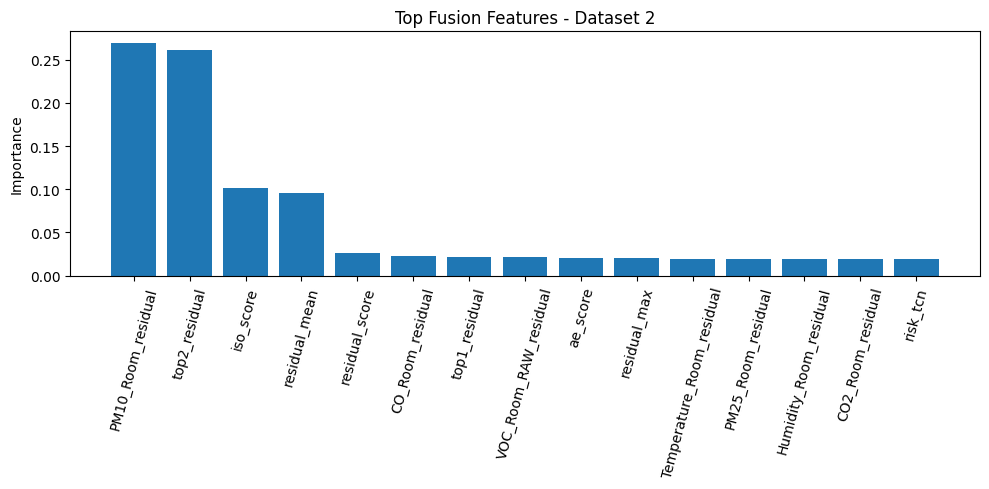

In [35]:
importance = pd.Series(
    xgb2.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))

plt.figure(figsize=(10, 5))
plt.bar(importance.index[:15], importance.values[:15])
plt.xticks(rotation=75)
plt.title("Top Fusion Features - Dataset 2")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [36]:
import os
import pickle
import torch

os.makedirs("results", exist_ok=True)
os.makedirs("models/dataset2", exist_ok=True)

# save outputs
df_search.to_csv("results/dataset2_threshold_search.csv", index=False)
df2_test_result.to_csv("results/dataset2_test_results_with_alarm.csv", index=False)

# save models
torch.save(model2.state_dict(), "models/dataset2/tcn_dataset2_forecaster.pt")
torch.save(ae2.state_dict(), "models/dataset2/ae_dataset2.pth")
xgb2.save_model("models/dataset2/xgb_dataset2.json")

# save scalers
with open("models/dataset2/scaler_dataset2.pkl", "wb") as f:
    pickle.dump(scaler2, f)

with open("models/dataset2/scaler_iso2.pkl", "wb") as f:
    pickle.dump(scaler_iso2, f)

print("Dataset 2 artifacts saved successfully.")

Dataset 2 artifacts saved successfully.


In [37]:
feature_sets = {
    "residual_only": ["residual_score", "risk_tcn"],
    "residual_iso": ["residual_score", "risk_tcn", "iso_score"],
    "residual_ae": ["residual_score", "risk_tcn", "ae_score"],
    "all_features": [c for c in fusion_train.columns if c != "label"]
}

for name, cols in feature_sets.items():
    X_train_ab = fusion_train[cols]
    X_val_ab = fusion_val[cols]

    model_ab = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

    model_ab.fit(X_train_ab, y_train)
    val_probs_ab = model_ab.predict_proba(X_val_ab)[:, 1]
    val_pred_ab = (val_probs_ab >= 0.5).astype(int)

    print(f"\n=== {name} ===")
    print(classification_report(y_val, val_pred_ab, zero_division=0))


=== residual_only ===
              precision    recall  f1-score   support

           0       0.98      0.59      0.74     21812
           1       0.23      0.93      0.37      2914

    accuracy                           0.63     24726
   macro avg       0.61      0.76      0.56     24726
weighted avg       0.90      0.63      0.70     24726


=== residual_iso ===
              precision    recall  f1-score   support

           0       0.99      0.51      0.68     21812
           1       0.21      0.97      0.35      2914

    accuracy                           0.57     24726
   macro avg       0.60      0.74      0.51     24726
weighted avg       0.90      0.57      0.64     24726


=== residual_ae ===
              precision    recall  f1-score   support

           0       0.99      0.60      0.75     21812
           1       0.24      0.93      0.38      2914

    accuracy                           0.64     24726
   macro avg       0.61      0.77      0.56     24726
weighted

In [ ]:
# ==========================================
# FIXED BASELINE EVALUATION (DATASET 2)
# ==========================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n==============================")
print(" BASELINE MODEL COMPARISON ")
print("==============================\n")

rows = []

# ------------------------------------------
# A. TCN-only baseline on test set
# ------------------------------------------

true_label_test = y_test.astype(int)


tcn_pred = (feat_test["risk_tcn"].values >= 0.5).astype(int)

tcn_acc = accuracy_score(true_label_test, tcn_pred)
tcn_prec = precision_score(true_label_test, tcn_pred, zero_division=0)
tcn_rec = recall_score(true_label_test, tcn_pred, zero_division=0)
tcn_f1 = f1_score(true_label_test, tcn_pred, zero_division=0)

print("----- TCN ONLY -----")
print("Accuracy :", tcn_acc)
print("Precision:", tcn_prec)
print("Recall   :", tcn_rec)
print("F1 Score :", tcn_f1)
print()

rows.append({
    "Model": "TCN-only",
    "Accuracy": tcn_acc,
    "Precision": tcn_prec,
    "Recall": tcn_rec,
    "F1": tcn_f1
})

# ------------------------------------------
# B. ISO-only baseline on test set
# ------------------------------------------
if "iso_score" in feat_test.columns:
    iso_pred = (feat_test["iso_score"].values >= 0.5).astype(int)

    iso_acc = accuracy_score(true_label_test, iso_pred)
    iso_prec = precision_score(true_label_test, iso_pred, zero_division=0)
    iso_rec = recall_score(true_label_test, iso_pred, zero_division=0)
    iso_f1 = f1_score(true_label_test, iso_pred, zero_division=0)

    print("----- ISOLATION FOREST ONLY -----")
    print("Accuracy :", iso_acc)
    print("Precision:", iso_prec)
    print("Recall   :", iso_rec)
    print("F1 Score :", iso_f1)
    print()

    rows.append({
        "Model": "Isolation Forest",
        "Accuracy": iso_acc,
        "Precision": iso_prec,
        "Recall": iso_rec,
        "F1": iso_f1
    })
else:
    print("ISO baseline skipped: iso_score not found in feat_test.\n")

# ------------------------------------------
# C. Hybrid Fusion baseline on df2_test_result
# ------------------------------------------

true_alarm_test = df2_test_result["TrueLabel"].astype(int)

if "FinalAlarm" not in df2_test_result.columns:
    raise ValueError("df2_test_result must contain FinalAlarm.")

fusion_pred = df2_test_result["FinalAlarm"].astype(int)

fusion_acc = accuracy_score(true_alarm_test, fusion_pred)
fusion_prec = precision_score(true_alarm_test, fusion_pred, zero_division=0)
fusion_rec = recall_score(true_alarm_test, fusion_pred, zero_division=0)
fusion_f1 = f1_score(true_alarm_test, fusion_pred, zero_division=0)

print("----- HYBRID FUSION -----")
print("Accuracy :", fusion_acc)
print("Precision:", fusion_prec)
print("Recall   :", fusion_rec)
print("F1 Score :", fusion_f1)
print()

rows.append({
    "Model": "Hybrid Fusion",
    "Accuracy": fusion_acc,
    "Precision": fusion_prec,
    "Recall": fusion_rec,
    "F1": fusion_f1
})

# ------------------------------------------
# D. Summary table
# ------------------------------------------
baseline_df = pd.DataFrame(rows)
print("----- SUMMARY TABLE -----")
print(baseline_df)

baseline_df.to_csv("results/dataset2_baseline_comparison.csv", index=False)
print("\nSaved: results/dataset2_baseline_comparison.csv")


 BASELINE MODEL COMPARISON 

----- TCN ONLY -----
Accuracy : 0.8874074671722775
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

----- ISOLATION FOREST ONLY -----
Accuracy : 0.11400447788288924
Precision: 0.11275173207829196
Recall   : 1.0
F1 Score : 0.20265388734593112

----- HYBRID FUSION -----
Accuracy : 0.440728563648466
Precision: 0.13705051299701707
Recall   : 0.7490146900752418
F1 Score : 0.23170495164731636

----- SUMMARY TABLE -----
              Model  Accuracy  Precision    Recall        F1
0          TCN-only  0.887407   0.000000  0.000000  0.000000
1  Isolation Forest  0.114004   0.112752  1.000000  0.202654
2     Hybrid Fusion  0.440729   0.137051  0.749015  0.231705

Saved: results/dataset2_baseline_comparison.csv
